# Train RC ConvFormer
---
Branch 1a inputs: Infrasound and seismic synthetic arrays

Branch 1b inputs: OHE features

Branch 2 inputs: Frequency ranges (octave spacing)

Outputs: RC metric ((mean + std) / array gain)

In [1]:
import warnings, sys, os, platform
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" 
#-----------------------------------------------------------------------------------------------------------------#
# Import Cardinal
pwd = os.getcwd(); current_subdir = os.path.dirname(pwd)
sys.path.append(current_subdir); import cardinal
#-----------------------------------------------------------------------------------------------------------------#
# Command to make all plots interactive
%matplotlib ipympl
#-----------------------------------------------------------------------------------------------------------------#
# Import packages as
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
#-----------------------------------------------------------------------------------------------------------------#
# ML packages
import tensorflow as tf
from keras.utils import *
from tensorflow.keras import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
#-----------------------------------------------------------------------------------------------------------------#
print(f"Python Platform: {platform.platform()}")
print(f"Tensorflow Version: {tf.__version__}")
print(f"Keras Version: {tf.keras.__version__}")
print()
print(f"Python {sys.version}")

Python Platform: macOS-13.6-arm64-arm-64bit
Tensorflow Version: 2.19.0
Keras Version: 3.9.2

Python 3.10.11 (main, Apr 20 2023, 13:58:42) [Clang 14.0.6 ]


---
Build model

In [2]:
# Build model for visualization
X_train_geometries, X_train_freqs = np.load('Training_Data/Split_1/X_train_final.npy'), np.load('Training_Data/Split_1/F_val_final.npy')
RC_Model_tmp = cardinal.build_RC_ConvFormer(X_train_geometries, X_train_freqs)
RC_Model_tmp.summary()

Model: "RC_ConvFormer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Geometries    │ (None, 10, 4, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 10, 2, 1)  │          0 │ Input_Geometries… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv_1 (Conv2D)     │ (None, 10, 2, 16) │        160 │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 2, 16) │         64 │ Conv_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 10, 2, 16) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 2, 16) │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv_1a (Conv2D)    │ (None, 10, 2, 16) │      2,320 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 2, 16) │         64 │ Conv_1a[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 10, 2, 16) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv_1b (Conv2D)    │ (None, 10, 2, 16) │      2,320 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 2, 16) │          0 │ Conv_1[0][0],     │
│                     │                   │            │ Conv_1b[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 2, 16) │         64 │ add[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 10, 2, 16) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv_2 (Conv2D)     │ (None, 10, 2, 32) │      4,640 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 2, 32) │        128 │ Conv_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 10, 2, 32) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 2, 32) │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv_2a (Conv2D)    │ (None, 10, 2, 32) │      9,248 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 2, 32) │        128 │ Conv_2a[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 10, 2, 32) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv_2b (Conv2D)    │ (None, 10, 2, 32) │      9,248 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 58,267 (227.61 KB)

 Trainable params: 57,811 (225.82 KB)

 Non-trainable params: 456 (1.78 KB)

---
Visualize model

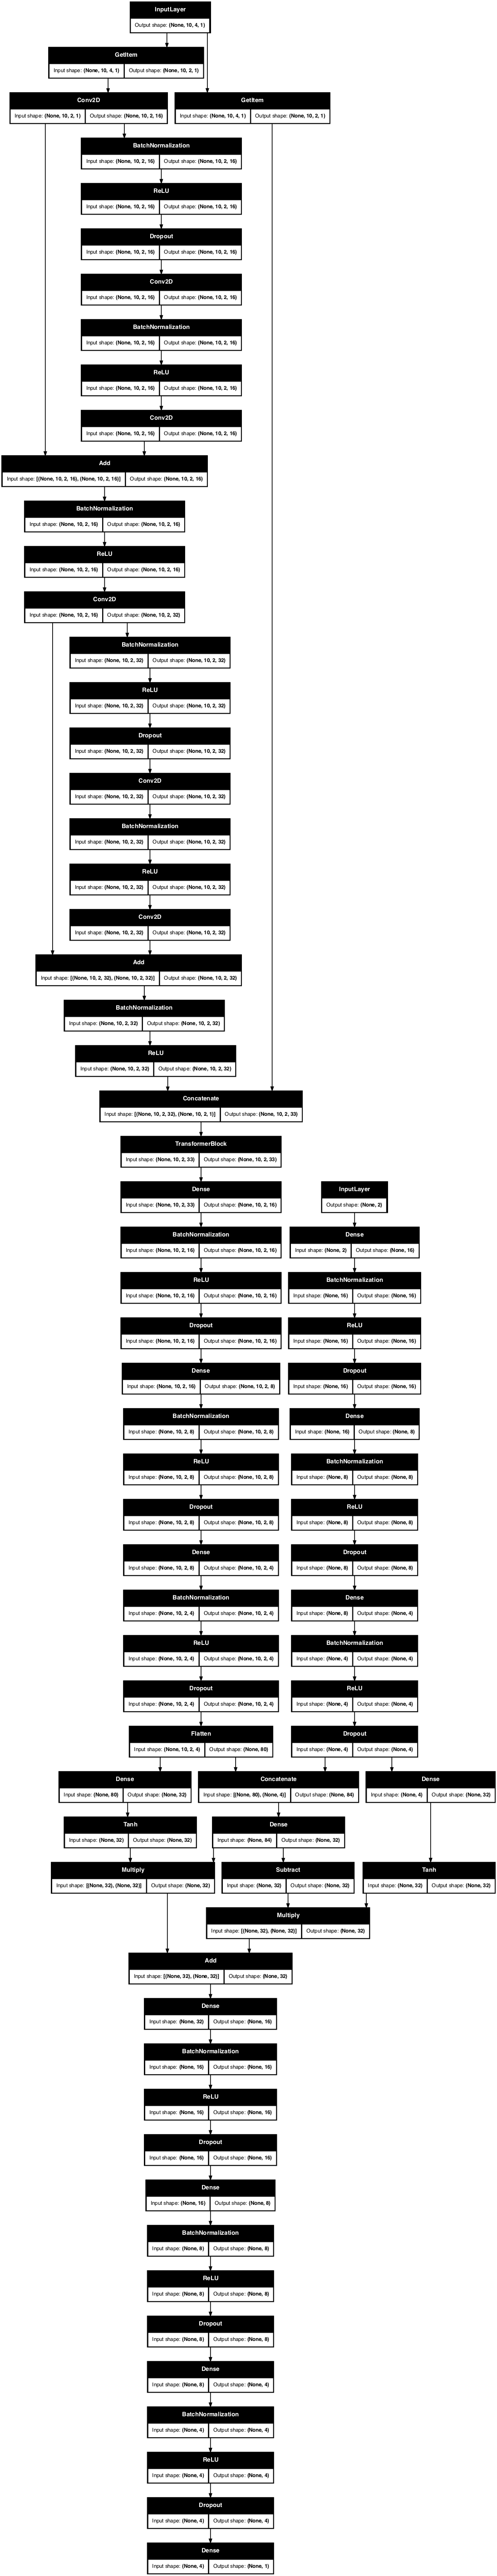

In [3]:
# Visualizing RC ConvFormer 
utils.plot_model(RC_Model_tmp, to_file='RC_ConvFormer.png', show_shapes=True, show_layer_names=False, rankdir='TB', expand_nested=False, dpi=60)

---
Train model with OHE

In [4]:
# Split 1
cardinal.train_models(split=0, batch_size=64, epochs=1000, lr=1e-3, patience=100)

Begin split # 1 of 5
Start training RC model
Epoch 1/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5561
Epoch 1: val_loss improved from inf to 0.15594, saving model to RC_Model_1.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 90s 14ms/step - loss: 0.5560 - val_loss: 0.1559
Epoch 2/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2587
Epoch 2: val_loss improved from 0.15594 to 0.11756, saving model to RC_Model_1.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.2587 - val_loss: 0.1176
Epoch 3/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2289
Epoch 3: val_loss improved from 0.11756 to 0.09385, saving model to RC_Model_1.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.2289 - val_loss: 0.0938
Epoch 4/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2146
Epoch 4: val_loss did not improve from 0.09385
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.2146 - val_loss: 0.0966
Epoch 5/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/s

Epoch 31/1000
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1831
Epoch 31: val_loss did not improve from 0.05784
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 0.1831 - val_loss: 0.0684
Epoch 32/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1830
Epoch 32: val_loss did not improve from 0.05784
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1830 - val_loss: 0.0642
Epoch 33/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1805
Epoch 33: val_loss did not improve from 0.05784
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1805 - val_loss: 0.0639
Epoch 34/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1803
Epoch 34: val_loss did not improve from 0.05784
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1803 - val_loss: 0.0715
Epoch 35/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1801
Epoch 35: val_loss did not improve from 0.05784
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1801 - val_loss: 0.0772


6064/6064 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.1763 - val_loss: 0.0692
Epoch 62/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1746
Epoch 62: val_loss did not improve from 0.05784
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1746 - val_loss: 0.0713
Epoch 63/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1754
Epoch 63: val_loss did not improve from 0.05784
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 88s 15ms/step - loss: 0.1754 - val_loss: 0.0591
Epoch 64/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1767
Epoch 64: val_loss did not improve from 0.05784
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1767 - val_loss: 0.0681
Epoch 65/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1762
Epoch 65: val_loss did not improve from 0.05784
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step - loss: 0.1762 - val_loss: 0.0731
Epoch 66/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1762
Epoch 66: val_loss did not improve from 0.05784


6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1760
Epoch 92: val_loss did not improve from 0.05710
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 0.1760 - val_loss: 0.0750
Epoch 93/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1742
Epoch 93: val_loss did not improve from 0.05710
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 0.1742 - val_loss: 0.0636
Epoch 94/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1746
Epoch 94: val_loss did not improve from 0.05710
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - loss: 0.1746 - val_loss: 0.0777
Epoch 95/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1741
Epoch 95: val_loss improved from 0.05710 to 0.05628, saving model to RC_Model_1.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.1741 - val_loss: 0.0563
Epoch 96/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1735
Epoch 96: val_loss did not improve from 0.05628
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.

6064/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1721
Epoch 152: val_loss did not improve from 0.05550
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.1721 - val_loss: 0.0600
Epoch 153/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1728
Epoch 153: val_loss did not improve from 0.05550
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step - loss: 0.1728 - val_loss: 0.0613
Epoch 154/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1702
Epoch 154: val_loss did not improve from 0.05550
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step - loss: 0.1702 - val_loss: 0.0665
Epoch 155/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1722
Epoch 155: val_loss did not improve from 0.05550
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step - loss: 0.1722 - val_loss: 0.0586
Epoch 156/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1722
Epoch 156: val_loss did not improve from 0.05550
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 90s 15ms/step - loss: 0.1722 - val_loss: 0.0669
Epoch

6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1715
Epoch 212: val_loss did not improve from 0.05181
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1715 - val_loss: 0.0623
Epoch 213/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1715
Epoch 213: val_loss did not improve from 0.05181
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.1715 - val_loss: 0.0558
Epoch 214/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1713
Epoch 214: val_loss did not improve from 0.05181
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1713 - val_loss: 0.0758
Epoch 215/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1715
Epoch 215: val_loss did not improve from 0.05181
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.1715 - val_loss: 0.0713
Epoch 216/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1691
Epoch 216: val_loss did not improve from 0.05181
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1691 - val_loss: 0.0677
Epoch

6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1701
Epoch 272: val_loss did not improve from 0.05181
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1701 - val_loss: 0.0653
Epoch 273/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1699
Epoch 273: val_loss did not improve from 0.05181
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1699 - val_loss: 0.0657
Epoch 274/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1715
Epoch 274: val_loss did not improve from 0.05181
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1715 - val_loss: 0.0737
Epoch 275/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1689
Epoch 275: val_loss did not improve from 0.05181
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step - loss: 0.1689 - val_loss: 0.0590
Epoch 276/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1701
Epoch 276: val_loss did not improve from 0.05181
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.1701 - val_loss: 0.0641
Epoch

In [5]:
# Split 2
cardinal.train_models(split=1, batch_size=64, epochs=1000, lr=1e-3, patience=100)

Begin split # 2 of 5
Start training RC model
Epoch 1/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4779
Epoch 1: val_loss improved from inf to 0.17089, saving model to RC_Model_2.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 90s 14ms/step - loss: 0.4778 - val_loss: 0.1709
Epoch 2/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2480
Epoch 2: val_loss improved from 0.17089 to 0.13637, saving model to RC_Model_2.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.2480 - val_loss: 0.1364
Epoch 3/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2206
Epoch 3: val_loss improved from 0.13637 to 0.12553, saving model to RC_Model_2.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.2206 - val_loss: 0.1255
Epoch 4/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2083
Epoch 4: val_loss did not improve from 0.12553
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 0.2083 - val_loss: 0.1320
Epoch 5/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/s

6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1720
Epoch 60: val_loss did not improve from 0.10039
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1720 - val_loss: 0.1115
Epoch 61/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1735
Epoch 61: val_loss did not improve from 0.10039
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - loss: 0.1735 - val_loss: 0.1217
Epoch 62/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1723
Epoch 62: val_loss did not improve from 0.10039
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1723 - val_loss: 0.1115
Epoch 63/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1724
Epoch 63: val_loss did not improve from 0.10039
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1724 - val_loss: 0.1201
Epoch 64/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1694
Epoch 64: val_loss did not improve from 0.10039
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 0.1694 - val_loss: 0.1212
Epoch 65/1000


6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1688 - val_loss: 0.1413
Epoch 91/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1688
Epoch 91: val_loss did not improve from 0.09999
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.1688 - val_loss: 0.1075
Epoch 92/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1686
Epoch 92: val_loss did not improve from 0.09999
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1686 - val_loss: 0.1042
Epoch 93/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1680
Epoch 93: val_loss improved from 0.09999 to 0.09631, saving model to RC_Model_2.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1680 - val_loss: 0.0963
Epoch 94/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1701
Epoch 94: val_loss did not improve from 0.09631
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 0.1701 - val_loss: 0.1091
Epoch 95/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1682
Epoch 95: 

Epoch 121/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1665
Epoch 121: val_loss did not improve from 0.09228
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1665 - val_loss: 0.1031
Epoch 122/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1673
Epoch 122: val_loss did not improve from 0.09228
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.1673 - val_loss: 0.0956
Epoch 123/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1658
Epoch 123: val_loss did not improve from 0.09228
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.1658 - val_loss: 0.0974
Epoch 124/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1673
Epoch 124: val_loss did not improve from 0.09228
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1673 - val_loss: 0.1173
Epoch 125/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1664
Epoch 125: val_loss improved from 0.09228 to 0.09100, saving model to RC_Model_2.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 

6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1643
Epoch 181: val_loss improved from 0.09010 to 0.08234, saving model to RC_Model_2.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 92s 15ms/step - loss: 0.1644 - val_loss: 0.0823
Epoch 182/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1655
Epoch 182: val_loss did not improve from 0.08234
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.1655 - val_loss: 0.1155
Epoch 183/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1639
Epoch 183: val_loss did not improve from 0.08234
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1639 - val_loss: 0.1155
Epoch 184/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1655
Epoch 184: val_loss did not improve from 0.08234
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1655 - val_loss: 0.1248
Epoch 185/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1662
Epoch 185: val_loss did not improve from 0.08234
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step -

6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1636
Epoch 241: val_loss did not improve from 0.07270
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1636 - val_loss: 0.1044
Epoch 242/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1643
Epoch 242: val_loss did not improve from 0.07270
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1643 - val_loss: 0.1224
Epoch 243/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1643
Epoch 243: val_loss did not improve from 0.07270
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1643 - val_loss: 0.1104
Epoch 244/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1640
Epoch 244: val_loss did not improve from 0.07270
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 0.1640 - val_loss: 0.0914
Epoch 245/1000
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1637
Epoch 245: val_loss did not improve from 0.07270
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1637 - val_loss: 0.1115
Epoch

6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1636
Epoch 301: val_loss did not improve from 0.07270
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1636 - val_loss: 0.1040
Epoch 302/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1631
Epoch 302: val_loss did not improve from 0.07270
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step - loss: 0.1631 - val_loss: 0.0941
Epoch 303/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1621
Epoch 303: val_loss did not improve from 0.07270
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.1621 - val_loss: 0.0990
Epoch 304/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1653
Epoch 304: val_loss did not improve from 0.07270
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1653 - val_loss: 0.0982
Epoch 305/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1619
Epoch 305: val_loss did not improve from 0.07270
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1619 - val_loss: 0.0984
Epoch

In [6]:
# Split 3
cardinal.train_models(split=2, batch_size=64, epochs=1000, lr=1e-3, patience=100)

Begin split # 3 of 5
Start training RC model
Epoch 1/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5116
Epoch 1: val_loss improved from inf to 0.15503, saving model to RC_Model_3.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 91s 14ms/step - loss: 0.5116 - val_loss: 0.1550
Epoch 2/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2586
Epoch 2: val_loss improved from 0.15503 to 0.13210, saving model to RC_Model_3.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.2586 - val_loss: 0.1321
Epoch 3/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2296
Epoch 3: val_loss improved from 0.13210 to 0.09619, saving model to RC_Model_3.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.2296 - val_loss: 0.0962
Epoch 4/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2186
Epoch 4: val_loss improved from 0.09619 to 0.09599, saving model to RC_Model_3.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.2186 - val_loss: 0.0960
Epoch 5/1000
60

Epoch 30/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1785
Epoch 30: val_loss did not improve from 0.05757
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.1785 - val_loss: 0.0597
Epoch 31/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1774
Epoch 31: val_loss improved from 0.05757 to 0.05690, saving model to RC_Model_3.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.1774 - val_loss: 0.0569
Epoch 32/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1792
Epoch 32: val_loss did not improve from 0.05690
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1792 - val_loss: 0.0641
Epoch 33/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1789
Epoch 33: val_loss did not improve from 0.05690
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step - loss: 0.1789 - val_loss: 0.0645
Epoch 34/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1782
Epoch 34: val_loss did not improve from 0.05690
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/s

6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1696
Epoch 90: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - loss: 0.1696 - val_loss: 0.0528
Epoch 91/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1722
Epoch 91: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1722 - val_loss: 0.0543
Epoch 92/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1713
Epoch 92: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1713 - val_loss: 0.0640
Epoch 93/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1720
Epoch 93: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1720 - val_loss: 0.0648
Epoch 94/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1701
Epoch 94: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1701 - val_loss: 0.0659
Epoch 95/1000


6064/6064 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.1712 - val_loss: 0.0526
Epoch 121/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1704
Epoch 121: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1704 - val_loss: 0.0581
Epoch 122/1000
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1709
Epoch 122: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.1709 - val_loss: 0.0655
Epoch 123/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1698
Epoch 123: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1698 - val_loss: 0.0653
Epoch 124/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1693
Epoch 124: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.1693 - val_loss: 0.0612
Epoch 125/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1700
Epoch 125: val_loss did not improve fro

Epoch 151/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1679
Epoch 151: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1679 - val_loss: 0.0618
Epoch 152/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1690
Epoch 152: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1690 - val_loss: 0.0508
Epoch 153/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1704
Epoch 153: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 0.1704 - val_loss: 0.0604
Epoch 154/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1696
Epoch 154: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1696 - val_loss: 0.0611
Epoch 155/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1696
Epoch 155: val_loss did not improve from 0.04641
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.1696 - val_los

In [7]:
# Split 4
cardinal.train_models(split=3, batch_size=64, epochs=1000, lr=1e-3, patience=100)

Begin split # 4 of 5
Start training RC model
Epoch 1/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5125
Epoch 1: val_loss improved from inf to 0.14420, saving model to RC_Model_4.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 14ms/step - loss: 0.5124 - val_loss: 0.1442
Epoch 2/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2541
Epoch 2: val_loss improved from 0.14420 to 0.11754, saving model to RC_Model_4.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.2541 - val_loss: 0.1175
Epoch 3/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2244
Epoch 3: val_loss improved from 0.11754 to 0.08157, saving model to RC_Model_4.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.2244 - val_loss: 0.0816
Epoch 4/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2148
Epoch 4: val_loss improved from 0.08157 to 0.07973, saving model to RC_Model_4.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.2148 - val_loss: 0.0797
Epoch 5/1000
60

6064/6064 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.1847 - val_loss: 0.0761
Epoch 31/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1835
Epoch 31: val_loss did not improve from 0.05756
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1835 - val_loss: 0.0709
Epoch 32/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1840
Epoch 32: val_loss did not improve from 0.05756
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.1840 - val_loss: 0.0707
Epoch 33/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1820
Epoch 33: val_loss did not improve from 0.05756
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1820 - val_loss: 0.0613
Epoch 34/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1829
Epoch 34: val_loss did not improve from 0.05756
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1829 - val_loss: 0.0607
Epoch 35/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1819
Epoch 35: val_loss did not improve from 0.05756


Epoch 61/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1785
Epoch 61: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 80s 13ms/step - loss: 0.1785 - val_loss: 0.0739
Epoch 62/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1778
Epoch 62: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 0.1778 - val_loss: 0.0657
Epoch 63/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1778
Epoch 63: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1778 - val_loss: 0.0594
Epoch 64/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1771
Epoch 64: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - loss: 0.1771 - val_loss: 0.0720
Epoch 65/1000
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1779
Epoch 65: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - loss: 0.1779 - val_loss: 0.0684


6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1774 - val_loss: 0.0736
Epoch 92/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1752
Epoch 92: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step - loss: 0.1752 - val_loss: 0.0712
Epoch 93/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1759
Epoch 93: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.1759 - val_loss: 0.0613
Epoch 94/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1760
Epoch 94: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1760 - val_loss: 0.0730
Epoch 95/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1764
Epoch 95: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 0.1764 - val_loss: 0.0738
Epoch 96/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1780
Epoch 96: val_loss did not improve from 0.05374


Epoch 122/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1762
Epoch 122: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1762 - val_loss: 0.0735
Epoch 123/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1760
Epoch 123: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1760 - val_loss: 0.0615
Epoch 124/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1752
Epoch 124: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1752 - val_loss: 0.0759
Epoch 125/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1756
Epoch 125: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 80s 13ms/step - loss: 0.1756 - val_loss: 0.0655
Epoch 126/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1755
Epoch 126: val_loss did not improve from 0.05374
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - loss: 0.1755 - val_los

In [8]:
# Split 5
cardinal.train_models(split=4, batch_size=64, epochs=1000, lr=1e-3, patience=100)

Begin split # 5 of 5
Start training RC model
Epoch 1/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5787
Epoch 1: val_loss improved from inf to 0.15695, saving model to RC_Model_5.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 90s 14ms/step - loss: 0.5786 - val_loss: 0.1570
Epoch 2/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2593
Epoch 2: val_loss improved from 0.15695 to 0.09438, saving model to RC_Model_5.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step - loss: 0.2593 - val_loss: 0.0944
Epoch 3/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2262
Epoch 3: val_loss improved from 0.09438 to 0.08606, saving model to RC_Model_5.keras
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.2262 - val_loss: 0.0861
Epoch 4/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2172
Epoch 4: val_loss did not improve from 0.08606
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - loss: 0.2172 - val_loss: 0.0953
Epoch 5/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/s

Epoch 61/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1810
Epoch 61: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.1810 - val_loss: 0.0752
Epoch 62/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1820
Epoch 62: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - loss: 0.1820 - val_loss: 0.0731
Epoch 63/1000
6060/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1816
Epoch 63: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.1816 - val_loss: 0.0867
Epoch 64/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1819
Epoch 64: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 87s 14ms/step - loss: 0.1819 - val_loss: 0.0729
Epoch 65/1000
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1830
Epoch 65: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - loss: 0.1830 - val_loss: 0.0807


6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.1777 - val_loss: 0.0676
Epoch 92/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1811
Epoch 92: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1811 - val_loss: 0.0747
Epoch 93/1000
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1789
Epoch 93: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 89s 15ms/step - loss: 0.1789 - val_loss: 0.0768
Epoch 94/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1796
Epoch 94: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 85s 14ms/step - loss: 0.1796 - val_loss: 0.0785
Epoch 95/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1791
Epoch 95: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - loss: 0.1791 - val_loss: 0.0815
Epoch 96/1000
6063/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1815
Epoch 96: val_loss did not improve from 0.06206


Epoch 122/1000
6062/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1789
Epoch 122: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.1789 - val_loss: 0.0659
Epoch 123/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1791
Epoch 123: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 83s 14ms/step - loss: 0.1791 - val_loss: 0.0837
Epoch 124/1000
6061/6064 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1779
Epoch 124: val_loss did not improve from 0.06206
6064/6064 ━━━━━━━━━━━━━━━━━━━━ 84s 14ms/step - loss: 0.1779 - val_loss: 0.0715
Epoch 124: early stopping
Restoring model weights from the end of the best epoch: 24.


---
Plot results

In [2]:
%%time
num_splits = 5; r2 = []; mse = []
for split in range(num_splits):
    #-----------------------------------------------------------------------------------------------------------------------#
    # Load histories and targets
    hist_file_tmp = pd.read_excel('RC_ConvFormer_Models/training_log_'+str(split+1)+'.xlsx')
    target_values_tmp = np.load('Training_Data/Split_'+str(split+1)+'/y_val_final.npy')
    #-----------------------------------------------------------------------------------------------------------------------#
    # Compute variance of target
    var_tmp = np.var(target_values_tmp)
    #-----------------------------------------------------------------------------------------------------------------------#
    # Compute R²
    r2_tmp = 1 - (hist_file_tmp['val_loss'] / var_tmp)
    r2.append(r2_tmp); mse.append(hist_file_tmp['val_loss'])

CPU times: user 247 ms, sys: 130 ms, total: 377 ms
Wall time: 4.86 s


Text(0.5, 0.98, 'RC ConvFormer Training')

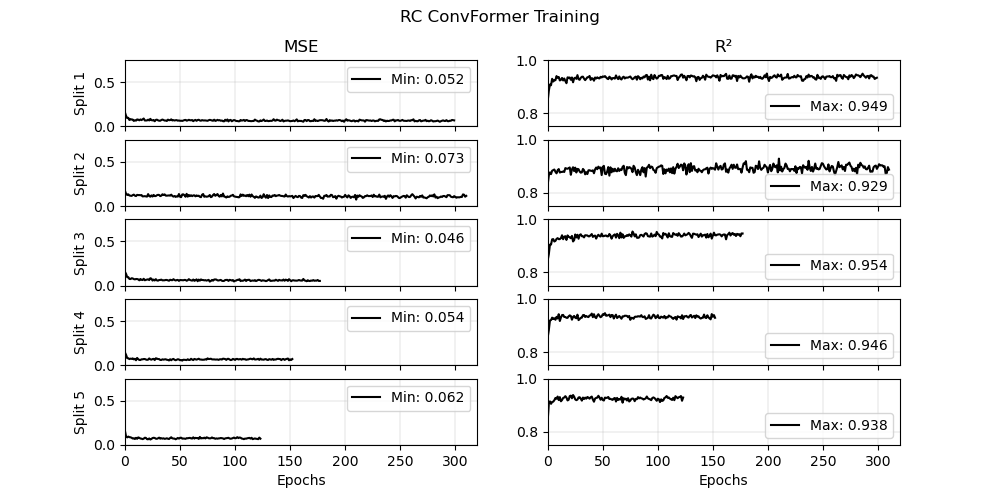

In [3]:
# Plot training histories
fig = plt.figure(figsize=(10,5))
#-----------------------------------------------------------------------------------------------------------------------#
# Split 1 - MSE
ax1 = fig.add_subplot(5,2,1)
plt.plot(mse[0], color='k'); ax1.set_ylabel('Split 1'); plt.title('MSE')
plt.xlim([0,320]); plt.ylim([0, 0.75]); ax1.tick_params(labelbottom=False)
plt.legend(['Min: %.3f'%np.array(mse[0]).min()], loc='upper right', prop = { "size": 10})
plt.grid(lw=0.25)
# Split 1 - R²
ax2 = fig.add_subplot(5,2,2, sharex=ax1)
plt.plot(r2[0], color='k'); plt.title('R²')
plt.ylim([0.75, 1]); ax2.tick_params(labelbottom=False)
plt.legend(['Max: %.3f'%np.array(r2[0]).max()], loc='lower right', prop = { "size": 10})
plt.grid(lw=0.25)
#-----------------------------------------------------------------------------------------------------------------------#
# Split 2 - MSE
ax3 = fig.add_subplot(5,2,3, sharex=ax1, sharey=ax1)
plt.plot(mse[1], color='k'); plt.ylabel('Split 2')
ax3.tick_params(labelbottom=False)
plt.legend(['Min: %.3f'%np.array(mse[1]).min()], loc='upper right', prop = { "size": 10})
plt.grid(lw=0.25)
# Split 2 - R²
ax4 = fig.add_subplot(5,2,4, sharex=ax1, sharey=ax2)
plt.plot(r2[1], color='k')
ax4.tick_params(labelbottom=False)
plt.legend(['Max: %.3f'%np.array(r2[1]).max()], loc='lower right', prop = { "size": 10})
plt.grid(lw=0.25)
#-----------------------------------------------------------------------------------------------------------------------#
# Split 3 - MSE
ax5 = fig.add_subplot(5,2,5, sharex=ax1, sharey=ax1)
plt.plot(mse[2], color='k'); plt.ylabel('Split 3')
ax5.tick_params(labelbottom=False)
plt.legend(['Min: %.3f'%np.array(mse[2]).min()], loc='upper right', prop = { "size": 10})
plt.grid(lw=0.25)
# Split 3 - R²
ax6 = fig.add_subplot(5,2,6, sharex=ax1, sharey=ax2)
plt.plot(r2[2], color='k')
ax6.tick_params(labelbottom=False)
plt.legend(['Max: %.3f'%np.array(r2[2]).max()], loc='lower right', prop = { "size": 10})
plt.grid(lw=0.25)
#-----------------------------------------------------------------------------------------------------------------------#
# Split 4 - MSE
ax7 = fig.add_subplot(5,2,7, sharex=ax1, sharey=ax1)
plt.plot(mse[3], color='k'); plt.ylabel('Split 4')
ax7.tick_params(labelbottom=False)
plt.legend(['Min: %.3f'%np.array(mse[3]).min()], loc='upper right', prop = { "size": 10})
plt.grid(lw=0.25)
# Split 4 - R²
ax8 = fig.add_subplot(5,2,8, sharex=ax1, sharey=ax2)
plt.plot(r2[3], color='k')
ax8.tick_params(labelbottom=False)
plt.legend(['Max: %.3f'%np.array(r2[3]).max()], loc='lower right', prop = { "size": 10})
plt.grid(lw=0.25)
#-----------------------------------------------------------------------------------------------------------------------#
# Split 5 - MSE
ax9 = fig.add_subplot(5,2,9, sharex=ax1, sharey=ax1)
plt.plot(mse[4], color='k'); plt.ylabel('Split 5')
plt.legend(['Min: %.3f'%np.array(mse[4]).min()], loc='upper right', prop = { "size": 10})
plt.grid(lw=0.25); plt.xlabel('Epochs')
# Split 5 - R²
ax10 = fig.add_subplot(5,2,10, sharex=ax1, sharey=ax2)
plt.plot(r2[4], color='k')
plt.legend(['Max: %.3f'%np.array(r2[4]).max()], loc='lower right', prop = { "size": 10})
plt.grid(lw=0.25); plt.xlabel('Epochs')
#-----------------------------------------------------------------------------------------------------------------------#
# Title
plt.suptitle('RC ConvFormer Training')